# Proyecto 1: Introducción a la IA Geoespacial (GeoAI)
## Parte 1 — Clasificación de Agua (Water Classification)

**Dataset:** MODIS Lake Powell (NASA CISTO) — HuggingFace  
**Objetivo:** Clasificar píxeles de agua vs. no-agua a partir de bandas espectrales de MODIS  
**Instrumento:** MODIS (Moderate Resolution Imaging Spectroradiometer)

---

## 1. Instalación e Importación de Librerías

In [1]:
# Instalar librerías no incluidas por defecto en Colab
!pip install datasets shap -q

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import datasets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 2. Variables Generales

In [3]:
# URL del dataset en HuggingFace
DATASET_URL = 'nasa-cisto-data-science-group/modis-lake-powell-toy-dataset'

# Semilla para reproducibilidad
RANDOM_STATE = 42

# Nombre de la columna objetivo (etiqueta)
LABEL_NAME = 'water'

# Columnas que no se usan para entrenamiento
COLS_TO_DROP = ['x_offset', 'y_offset', 'year', 'julian_day']

# Nombres de las bandas espectrales de MODIS + índices derivados
BAND_NAMES = [
    'sur_refl_b01_1',  # Banda 1 - Rojo
    'sur_refl_b02_1',  # Banda 2 - NIR (Infrarrojo cercano)
    'sur_refl_b03_1',  # Banda 3 - Azul
    'sur_refl_b04_1',  # Banda 4 - Verde
    'sur_refl_b05_1',  # Banda 5 - Infrarrojo de onda corta
    'sur_refl_b06_1',  # Banda 6 - SWIR
    'sur_refl_b07_1',  # Banda 7 - SWIR
    'ndvi',            # Índice de Vegetación (NDVI)
    'ndwi1',           # Índice de Agua 1 (NDWI)
    'ndwi2'            # Índice de Agua 2 (NDWI2)
]

# Etiquetas legibles para clases
CLASS_LABELS = {0: 'No Agua', 1: 'Agua'}

# Carpeta de salida
os.makedirs('output', exist_ok=True)
print('✅ Variables configuradas')

✅ Variables configuradas


## 3. Carga del Dataset

In [4]:
%%time
# Cargar dataset desde HuggingFace
dataset = datasets.load_dataset(DATASET_URL, split='train')
df = pd.DataFrame(dataset)
print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/200 [00:00<?, ? examples/s]

✅ Dataset cargado: 800 filas × 11 columnas
CPU times: user 526 ms, sys: 23.8 ms, total: 550 ms
Wall time: 3.08 s


,water,sur_refl_b01_1,sur_refl_b02_1,sur_refl_b03_1,sur_refl_b04_1,sur_refl_b05_1,sur_refl_b06_1,sur_refl_b07_1,ndvi,ndwi1,ndwi2
0,0,2031,3113,776,1200,3626,3480,2957,2103,-556,257
1,1,410,494,183,319,295,329,307,929,2004,2334
2,0,1609,2615,797,1000,2143,1708,1107,2381,2098,4051
3,0,2593,3315,1250,1944,3923,4194,3909,1222,-1170,-822
4,0,2485,3365,905,1527,4520,4646,4137,1504,-1599,-1029


In [5]:
# Inspección inicial del dataset
print('--- Tipos de datos ---')
print(df.dtypes)
print(f'\n--- Valores nulos ---')
print(df.isnull().sum())

--- Tipos de datos ---
water             int64
sur_refl_b01_1    int64
sur_refl_b02_1    int64
sur_refl_b03_1    int64
sur_refl_b04_1    int64
sur_refl_b05_1    int64
sur_refl_b06_1    int64
sur_refl_b07_1    int64
ndvi              int64
ndwi1             int64
ndwi2             int64
dtype: object

--- Valores nulos ---
water             0
sur_refl_b01_1    0
sur_refl_b02_1    0
sur_refl_b03_1    0
sur_refl_b04_1    0
sur_refl_b05_1    0
sur_refl_b06_1    0
sur_refl_b07_1    0
ndvi              0
ndwi1             0
ndwi2             0
dtype: int64


In [6]:
# Estadísticas descriptivas
df[BAND_NAMES + [LABEL_NAME]].describe().round(4)

,sur_refl_b01_1,sur_refl_b02_1,sur_refl_b03_1,sur_refl_b04_1,sur_refl_b05_1,sur_refl_b06_1,sur_refl_b07_1,ndvi,ndwi1,ndwi2,water
count,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000
mean,1209.7588,1577.2538,743.0000,1028.3950,1969.3712,1932.6588,1587.6962,87.1312,-2336.0375,-914.2912,0.5062
std,1287.8865,1554.8288,1004.3345,1065.5829,1467.6132,1541.9108,1395.2664,2518.7368,3404.0387,3863.6956,0.5003
min,8.0000,1.0000,-100.0000,6.0000,-92.0000,51.0000,0.0000,-9493.0000,-9862.0000,-9692.0000,0.0000
25%,238.2500,168.0000,286.0000,413.0000,553.5000,511.2500,316.7500,-1533.0000,-4577.5000,-2846.2500,0.0000
50%,886.5000,1394.0000,540.0000,809.5000,1818.5000,1498.5000,1174.0000,733.5000,-1582.0000,-703.5000,1.0000
75%,1893.2500,2667.7500,857.0000,1313.2500,3210.7500,3254.2500,2672.0000,1729.5000,-766.5000,869.0000,1.0000
max,9222.0000,8837.0000,8909.0000,9162.0000,6382.0000,6610.0000,6128.0000,8587.0000,8823.0000,10000.0000,1.0000


## 4. Análisis Exploratorio de Datos (EDA)

Realizamos al menos **7 visualizaciones** para entender la distribución de los datos espectrales de MODIS.

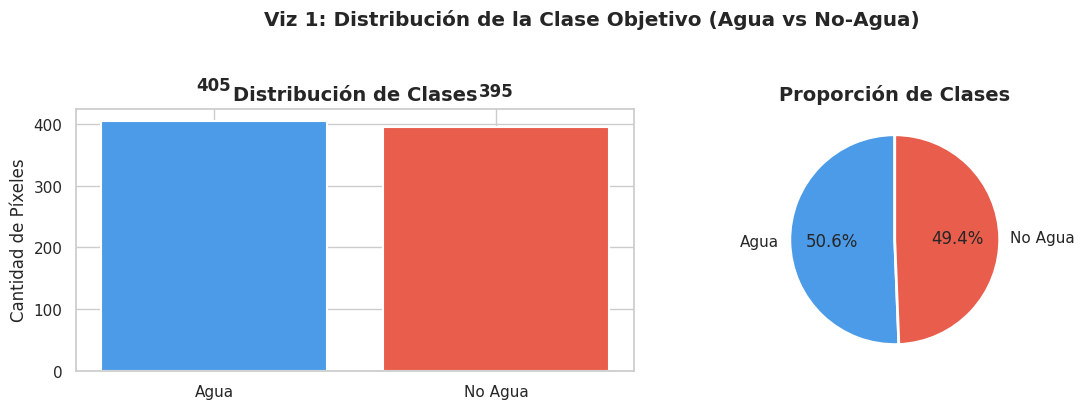

In [7]:
# --- Visualización 1: Distribución de la clase objetivo ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[LABEL_NAME].value_counts()
labels = [CLASS_LABELS[i] for i in counts.index]
colors = ['#4C9BE8', '#E85D4C']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Clases', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de Píxeles')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.suptitle('Viz 1: Distribución de la Clase Objetivo (Agua vs No-Agua)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('output/viz1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

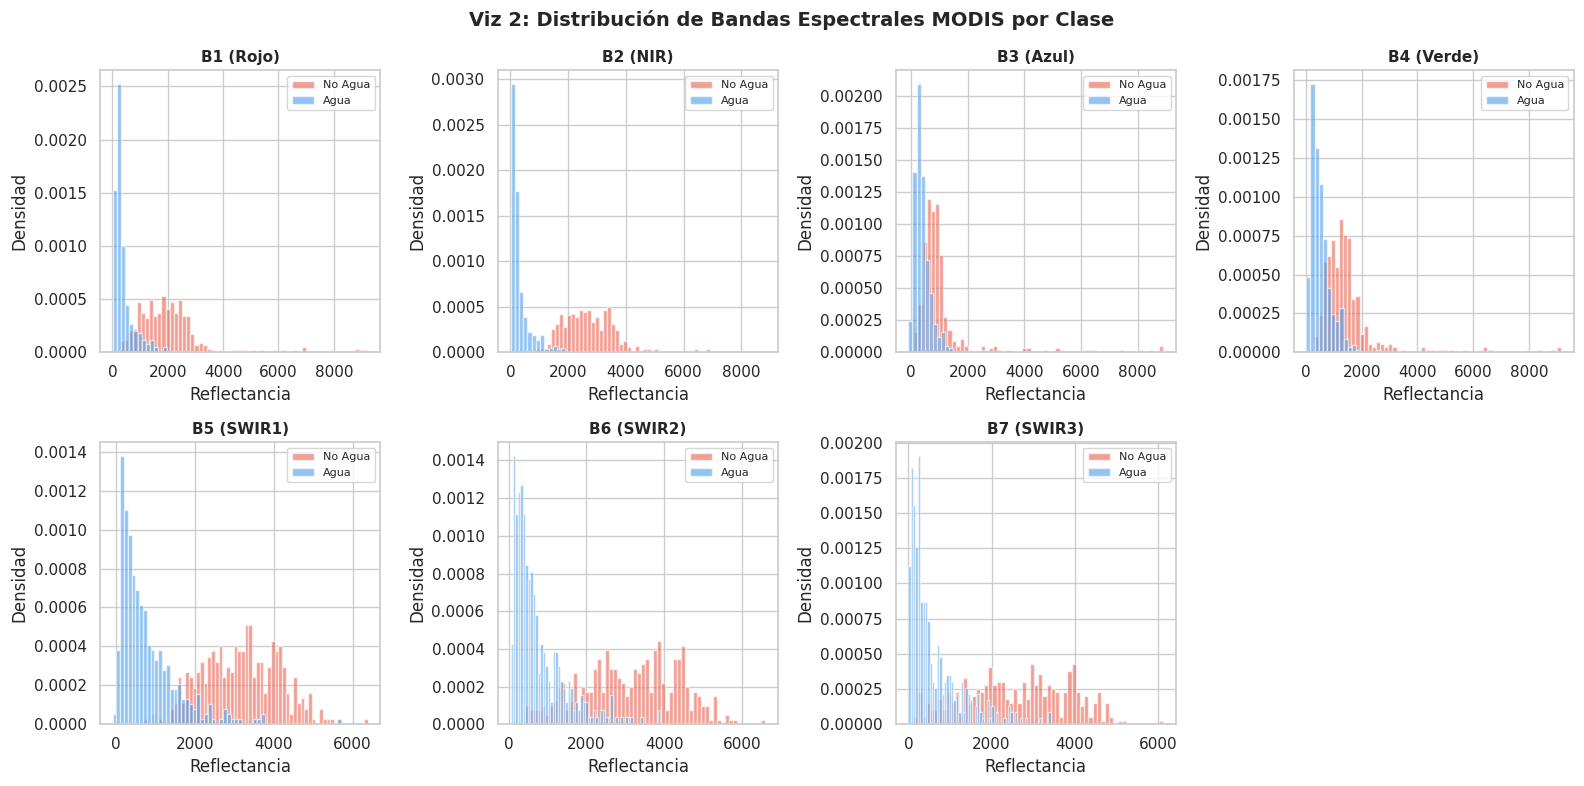

In [8]:
# --- Visualización 2: Histogramas de Bandas Espectrales (por clase) ---
bands_to_plot = ['sur_refl_b01_1', 'sur_refl_b02_1', 'sur_refl_b03_1',
                 'sur_refl_b04_1', 'sur_refl_b05_1', 'sur_refl_b06_1', 'sur_refl_b07_1']
band_labels = ['B1 (Rojo)', 'B2 (NIR)', 'B3 (Azul)', 'B4 (Verde)',
               'B5 (SWIR1)', 'B6 (SWIR2)', 'B7 (SWIR3)']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (band, label) in enumerate(zip(bands_to_plot, band_labels)):
    for cls, color, name in [(0, '#E85D4C', 'No Agua'), (1, '#4C9BE8', 'Agua')]:
        subset = df[df[LABEL_NAME] == cls][band]
        axes[i].hist(subset, bins=60, alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Reflectancia')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Viz 2: Distribución de Bandas Espectrales MODIS por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/viz2_band_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

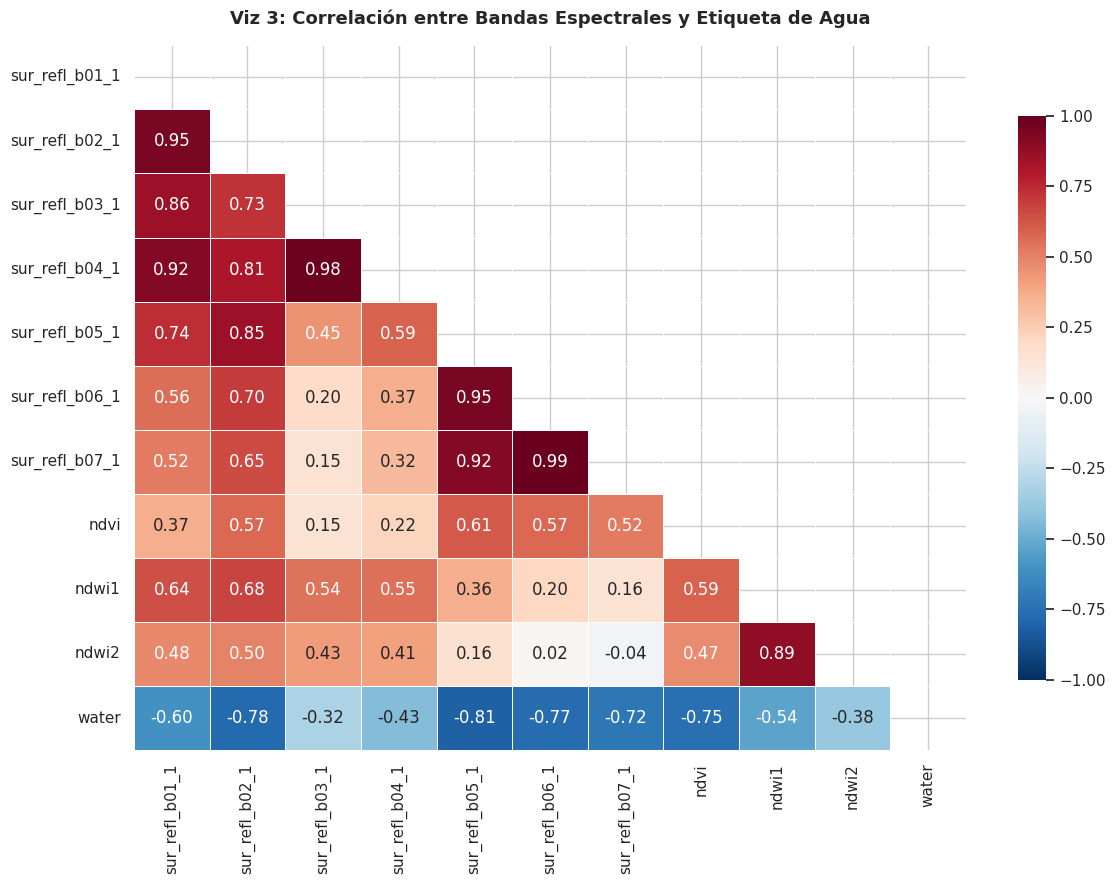

In [9]:
# --- Visualización 3: Mapa de Correlación (Heatmap) ---
fig, ax = plt.subplots(figsize=(12, 9))

corr_matrix = df[BAND_NAMES + [LABEL_NAME]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Viz 3: Correlación entre Bandas Espectrales y Etiqueta de Agua',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('output/viz3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

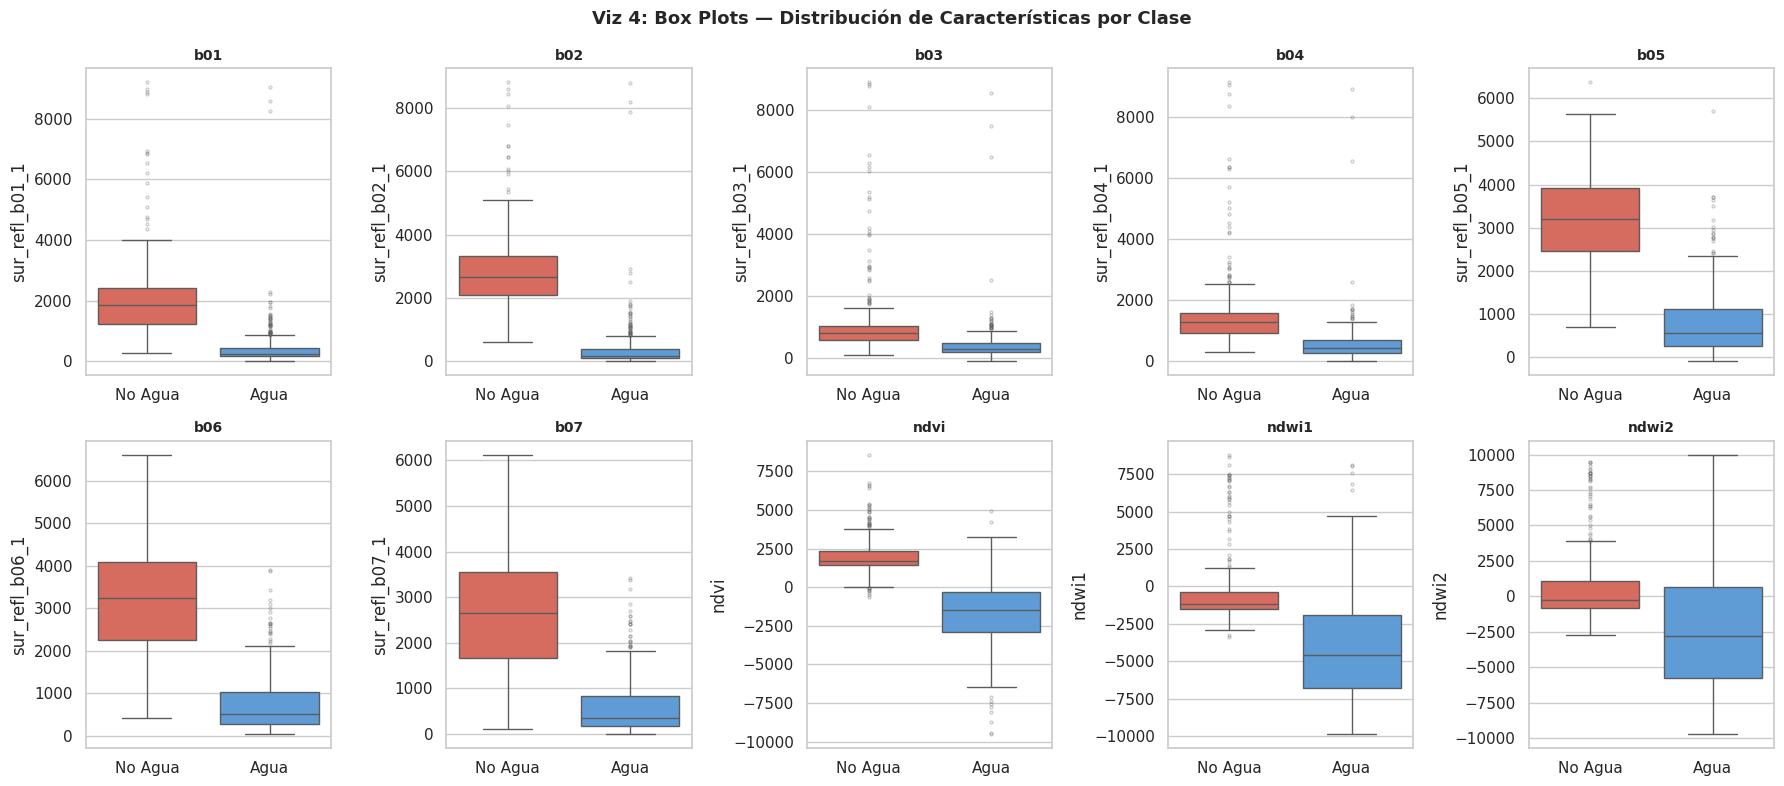

In [10]:
# --- Visualización 4: Box Plots por Clase ---
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, band in enumerate(BAND_NAMES):
    plot_df = df[[band, LABEL_NAME]].copy()
    plot_df[LABEL_NAME] = plot_df[LABEL_NAME].map(CLASS_LABELS)
    sns.boxplot(data=plot_df, x=LABEL_NAME, y=band,
                palette=['#E85D4C', '#4C9BE8'], ax=axes[i],
                flierprops={'markersize': 2, 'alpha': 0.3})
    axes[i].set_title(band.replace('sur_refl_', '').replace('_1', ''), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Viz 4: Box Plots — Distribución de Características por Clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/viz4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

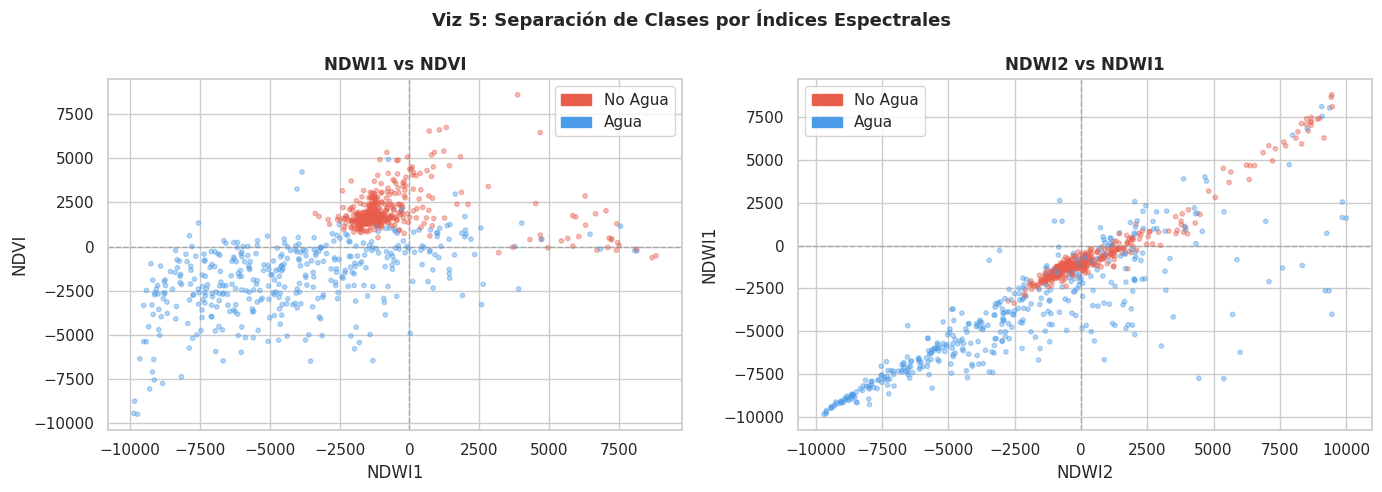

In [11]:
# --- Visualización 5: Scatter Plot NDWI vs NDVI (separación de clases) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Muestra para no saturar el gráfico
sample = df.sample(n=min(5000, len(df)), random_state=RANDOM_STATE)
colors_map = sample[LABEL_NAME].map({0: '#E85D4C', 1: '#4C9BE8'})

axes[0].scatter(sample['ndwi1'], sample['ndvi'],
                c=colors_map, alpha=0.4, s=10)
axes[0].axhline(0, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[0].set_xlabel('NDWI1', fontsize=12)
axes[0].set_ylabel('NDVI', fontsize=12)
axes[0].set_title('NDWI1 vs NDVI', fontsize=12, fontweight='bold')
p1 = mpatches.Patch(color='#E85D4C', label='No Agua')
p2 = mpatches.Patch(color='#4C9BE8', label='Agua')
axes[0].legend(handles=[p1, p2])

axes[1].scatter(sample['ndwi2'], sample['ndwi1'],
                c=colors_map, alpha=0.4, s=10)
axes[1].axhline(0, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[1].set_xlabel('NDWI2', fontsize=12)
axes[1].set_ylabel('NDWI1', fontsize=12)
axes[1].set_title('NDWI2 vs NDWI1', fontsize=12, fontweight='bold')
axes[1].legend(handles=[p1, p2])

plt.suptitle('Viz 5: Separación de Clases por Índices Espectrales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/viz5_scatter_indices.png', dpi=150, bbox_inches='tight')
plt.show()

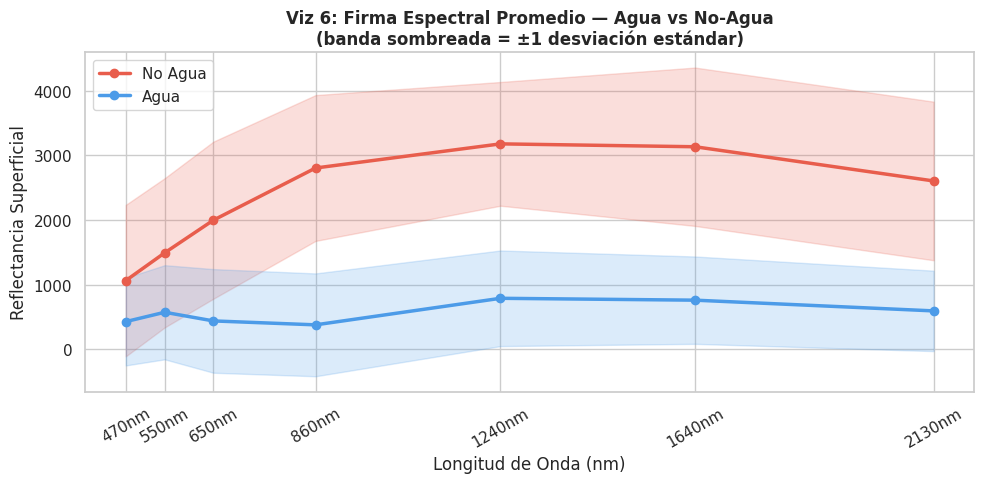

In [12]:
# --- Visualización 6: Firma Espectral Promedio (Agua vs No-Agua) ---
# La 'firma espectral' es el patrón de reflectancia única de cada tipo de superficie
spectral_bands = [
    'sur_refl_b03_1',  # Azul (~470nm)
    'sur_refl_b04_1',  # Verde (~550nm)
    'sur_refl_b01_1',  # Rojo (~650nm)
    'sur_refl_b02_1',  # NIR (~860nm)
    'sur_refl_b05_1',  # SWIR1 (~1240nm)
    'sur_refl_b06_1',  # SWIR2 (~1640nm)
    'sur_refl_b07_1',  # SWIR3 (~2130nm)
]
wavelengths = [470, 550, 650, 860, 1240, 1640, 2130]

fig, ax = plt.subplots(figsize=(10, 5))

for cls, color, label in [(0, '#E85D4C', 'No Agua'), (1, '#4C9BE8', 'Agua')]:
    subset = df[df[LABEL_NAME] == cls][spectral_bands]
    mean_vals = subset.mean().values
    std_vals = subset.std().values
    ax.plot(wavelengths, mean_vals, color=color, marker='o', linewidth=2.5, label=label)
    ax.fill_between(wavelengths,
                    mean_vals - std_vals,
                    mean_vals + std_vals,
                    alpha=0.2, color=color)

ax.set_xlabel('Longitud de Onda (nm)', fontsize=12)
ax.set_ylabel('Reflectancia Superficial', fontsize=12)
ax.set_title('Viz 6: Firma Espectral Promedio — Agua vs No-Agua\n(banda sombreada = ±1 desviación estándar)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(wavelengths)
ax.set_xticklabels([f'{w}nm' for w in wavelengths], rotation=30)
plt.tight_layout()
plt.savefig('output/viz6_spectral_signature.png', dpi=150, bbox_inches='tight')
plt.show()

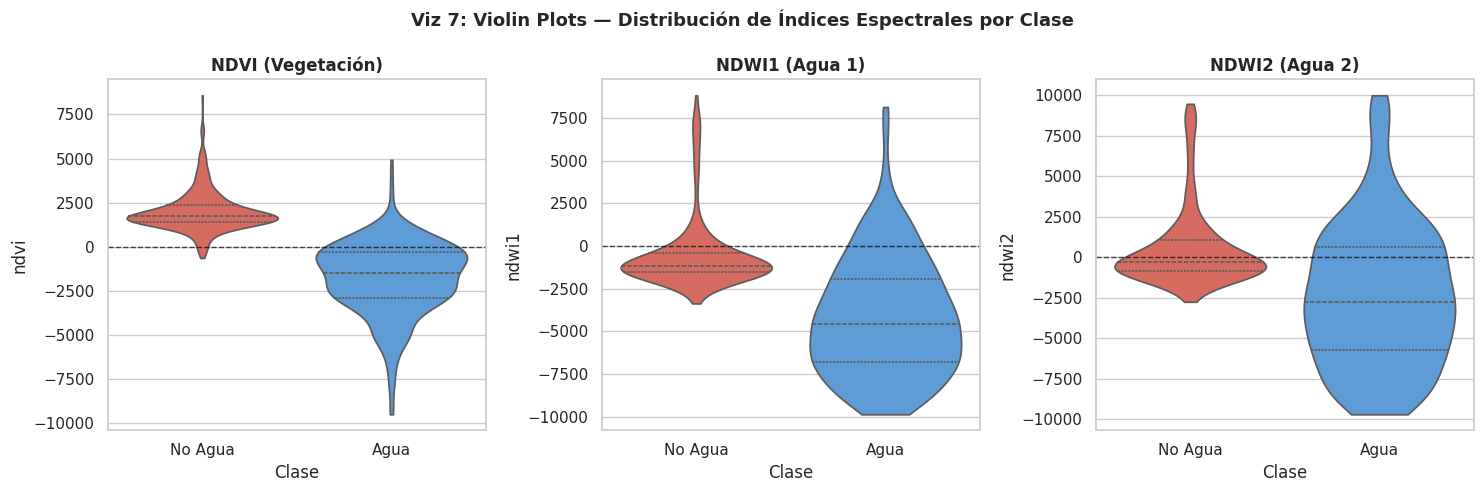

In [13]:
# --- Visualización 7: Violin Plot de índices de agua por clase ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = ['ndvi', 'ndwi1', 'ndwi2']
index_titles = ['NDVI (Vegetación)', 'NDWI1 (Agua 1)', 'NDWI2 (Agua 2)']

for ax, idx, title in zip(axes, indices, index_titles):
    plot_df = df[[idx, LABEL_NAME]].copy()
    plot_df[LABEL_NAME] = plot_df[LABEL_NAME].map(CLASS_LABELS)
    sns.violinplot(data=plot_df, x=LABEL_NAME, y=idx,
                   palette=['#E85D4C', '#4C9BE8'], ax=ax,
                   inner='quartile', cut=0)
    ax.axhline(0, color='black', linestyle='--', lw=1, alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Clase')

plt.suptitle('Viz 7: Violin Plots — Distribución de Índices Espectrales por Clase',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/viz7_violin_indices.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ingeniería de Características (Feature Engineering)

In [14]:
# Copiar el dataframe para trabajar en la versión procesada
df_fe = df.copy()

# --- Feature 1: Ratio NIR / Rojo (indicador de vegetación y agua) ---
df_fe['nir_red_ratio'] = df_fe['sur_refl_b02_1'] / (df_fe['sur_refl_b01_1'] + 1e-6)

# --- Feature 2: Ratio Azul / NIR (sensible a agua clara) ---
df_fe['blue_nir_ratio'] = df_fe['sur_refl_b03_1'] / (df_fe['sur_refl_b02_1'] + 1e-6)

# --- Feature 3: Suma total de reflectancia de todas las bandas ---
df_fe['total_reflectance'] = df_fe[['sur_refl_b01_1','sur_refl_b02_1','sur_refl_b03_1',
                                    'sur_refl_b04_1','sur_refl_b05_1','sur_refl_b06_1',
                                    'sur_refl_b07_1']].sum(axis=1)

# --- Feature 4: Diferencia SWIR - NIR (discriminador de agua vs tierra) ---
df_fe['swir_nir_diff'] = df_fe['sur_refl_b06_1'] - df_fe['sur_refl_b02_1']

# --- Feature 5: NDWI combinado promedio ---
df_fe['ndwi_mean'] = (df_fe['ndwi1'] + df_fe['ndwi2']) / 2

# Nuevas features creadas
new_features = ['nir_red_ratio', 'blue_nir_ratio', 'total_reflectance', 'swir_nir_diff', 'ndwi_mean']
print(f'✅ {len(new_features)} nuevas características creadas:')
for f in new_features:
    print(f'   - {f}')

df_fe[new_features].describe().round(4)

✅ 5 nuevas características creadas:
   - nir_red_ratio
   - blue_nir_ratio
   - total_reflectance
   - swir_nir_diff
   - ndwi_mean


,nir_red_ratio,blue_nir_ratio,total_reflectance,swir_nir_diff,ndwi_mean
count,800.0000,800.0000,800.0000,800.0000,800.0000
mean,1.1645,1.6552,10048.1338,355.4050,-1625.1644
std,0.7226,6.8040,7995.2246,1201.0634,3533.3184
min,0.0260,-4.3478,205.0000,-7727.0000,-9777.0000
25%,0.7340,0.2985,2692.0000,115.7500,-3426.0000
50%,1.1584,0.5517,8514.5000,408.5000,-1134.5000
75%,1.4185,1.6070,16382.0000,898.2500,-26.8750
max,13.1589,128.9999,44020.0000,3643.0000,9138.0000


In [15]:
# Definir columnas finales de features
FEATURE_COLS = BAND_NAMES + new_features

# Preparar X (características) e y (etiqueta)
X = df_fe[FEATURE_COLS].values
y = df_fe[LABEL_NAME].values

print(f'✅ X shape: {X.shape}  |  y shape: {y.shape}')
print(f'   Clases: {np.unique(y, return_counts=True)}')

✅ X shape: (800, 15)  |  y shape: (800,)
   Clases: (array([0, 1]), array([395, 405]))


## 6. División del Dataset (Train / Test Split)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y  # Mantiene proporción de clases en ambos subsets
)

print(f'✅ Entrenamiento : {X_train.shape[0]:,} muestras')
print(f'   Prueba        : {X_test.shape[0]:,} muestras')
print(f'   Proporción agua en train: {y_train.mean():.3f}')
print(f'   Proporción agua en test : {y_test.mean():.3f}')

✅ Entrenamiento : 640 muestras
   Prueba        : 160 muestras
   Proporción agua en train: 0.506
   Proporción agua en test : 0.506


## 7. Inicialización y Entrenamiento del Modelo

In [17]:
# Random Forest — buen punto de partida para datos geoespaciales tabulares
# Es robusto a outliers y no requiere normalización
model = RandomForestClassifier(
    n_estimators=150,      # Número de árboles
    max_depth=20,          # Profundidad máxima
    min_samples_split=5,   # Mínimo de muestras para dividir un nodo
    class_weight='balanced',  # Maneja el desbalance de clases
    random_state=RANDOM_STATE,
    n_jobs=-1              # Usa todos los núcleos disponibles
)

print('🌲 Entrenando Random Forest...')
%time model.fit(X_train, y_train)
print('✅ Modelo entrenado exitosamente')

🌲 Entrenando Random Forest...
CPU times: user 491 ms, sys: 37.4 ms, total: 528 ms
Wall time: 395 ms
✅ Modelo entrenado exitosamente


## 8. Predicciones y Evaluación del Modelo

In [18]:
# Predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilidad de clase 'Agua'

# Métricas básicas
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'🎯 Exactitud (Accuracy) : {acc:.4f} ({acc*100:.2f}%)')
print(f'📈 AUC-ROC              : {auc:.4f}')
print()
print('--- Reporte de Clasificación ---')
print(classification_report(y_test, y_pred, target_names=['No Agua', 'Agua']))

🎯 Exactitud (Accuracy) : 0.9750 (97.50%)
📈 AUC-ROC              : 0.9975

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

     No Agua       0.99      0.96      0.97        79
        Agua       0.96      0.99      0.98        81

    accuracy                           0.97       160
   macro avg       0.98      0.97      0.97       160
weighted avg       0.98      0.97      0.97       160



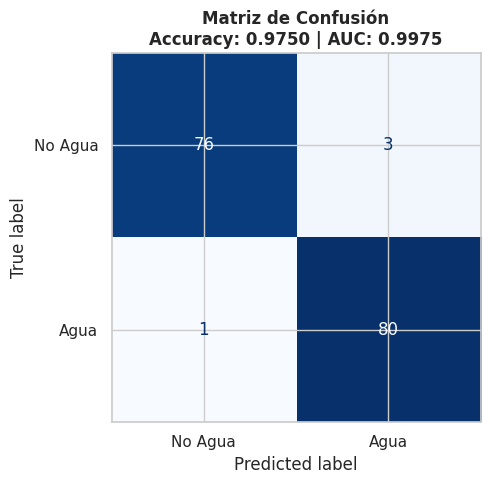

In [19]:
# --- Gráfico de Evaluación 1: Matriz de Confusión ---
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Agua', 'Agua'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión\nAccuracy: {acc:.4f} | AUC: {auc:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output/eval1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

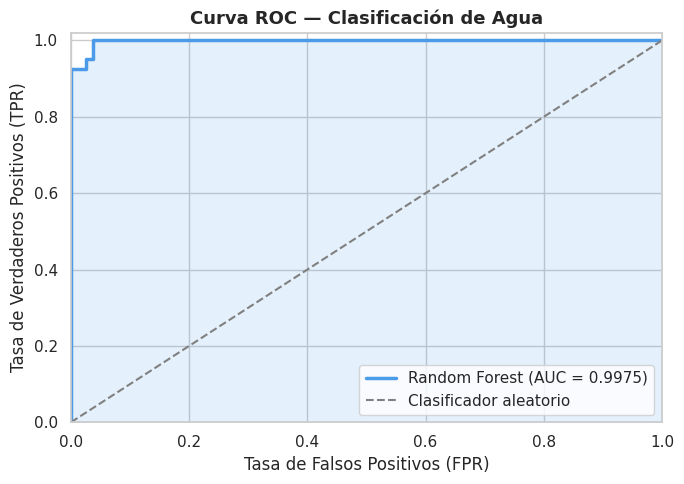

In [20]:
# --- Gráfico de Evaluación 2: Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#4C9BE8', lw=2.5, label=f'Random Forest (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Clasificador aleatorio')
ax.fill_between(fpr, tpr, alpha=0.15, color='#4C9BE8')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC — Clasificación de Agua', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('output/eval2_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. IA Explicable (XAI) — Importancia de Características

Utilizamos dos enfoques complementarios:
1. **Feature Importance del modelo** (Gini Impurity)
2. **SHAP values** (SHapley Additive exPlanations) — explicaciones basadas en teoría de juegos

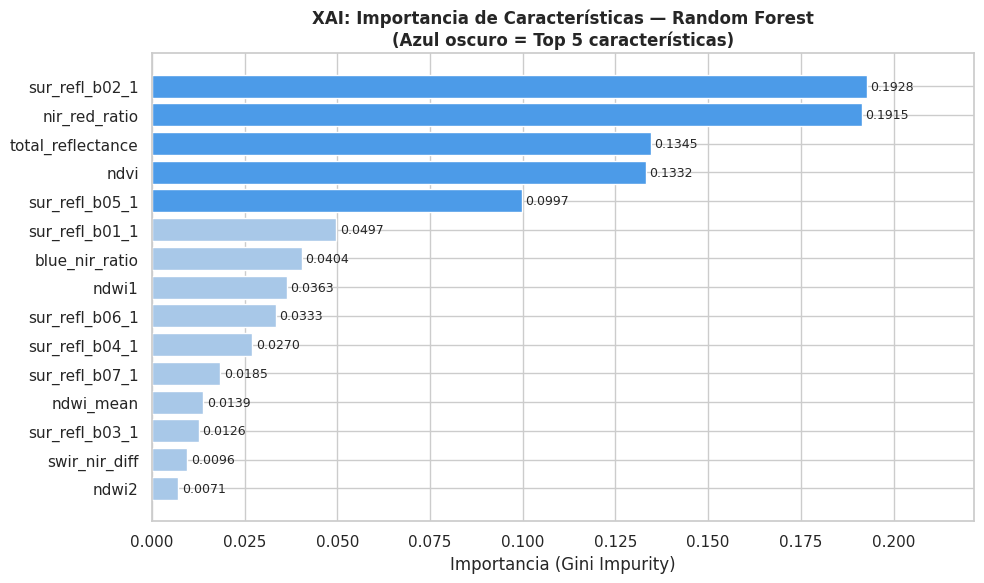


Top 5 características más importantes:
          Feature  Importance
   sur_refl_b02_1    0.192786
    nir_red_ratio    0.191470
total_reflectance    0.134543
             ndvi    0.133166
   sur_refl_b05_1    0.099676


In [21]:
# --- XAI 1: Importancia de Características del Random Forest (Gini) ---
importances = model.feature_importances_
fi_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#4C9BE8' if i < 5 else '#A8C8E8' for i in range(len(fi_df))]
bars = ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
               color=colors_fi[::-1], edgecolor='white')

for bar, val in zip(bars, fi_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Importancia (Gini Impurity)', fontsize=12)
ax.set_title('XAI: Importancia de Características — Random Forest\n(Azul oscuro = Top 5 características)',
             fontsize=12, fontweight='bold')
ax.set_xlim([0, fi_df['Importance'].max() * 1.15])
plt.tight_layout()
plt.savefig('output/xai1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 características más importantes:')
print(fi_df.head().to_string(index=False))

In [22]:
# --- XAI 2: SHAP Values — explicaciones globales ---
# Usamos una muestra para acelerar el cálculo
print('🔍 Calculando SHAP values (esto puede tomar ~1-2 minutos)...')

# Muestra representativa del conjunto de prueba
sample_size = min(500, len(X_test))
idx_sample = np.random.RandomState(RANDOM_STATE).choice(len(X_test), sample_size, replace=False)
X_shap_sample = X_test[idx_sample]

# TreeExplainer es el más eficiente para modelos basados en árboles
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_sample)

# shap_values[1] corresponde a la clase 'Agua'
print(f'✅ SHAP values calculados para {sample_size} muestras')

🔍 Calculando SHAP values (esto puede tomar ~1-2 minutos)...
✅ SHAP values calculados para 160 muestras


In [23]:
# --- SHAP: Beeswarm Plot (resumen global) ---
print('🔍 Calculando SHAP values...')

sample_size = min(500, len(X_test))
idx_sample = np.random.RandomState(RANDOM_STATE).choice(len(X_test), sample_size, replace=False)
X_shap_sample = X_test[idx_sample]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_sample)

# Compatibilidad con versiones nuevas y viejas de SHAP
if isinstance(shap_values, list):
    sv_water = shap_values[1]   # API antigua: lista de arrays
else:
    sv_water = shap_values[:, :, 1]  # API nueva: array 3D

print(f'✅ SHAP values: shape={sv_water.shape}  |  muestras={sample_size}')

🔍 Calculando SHAP values...
✅ SHAP values: shape=(160, 15)  |  muestras=160


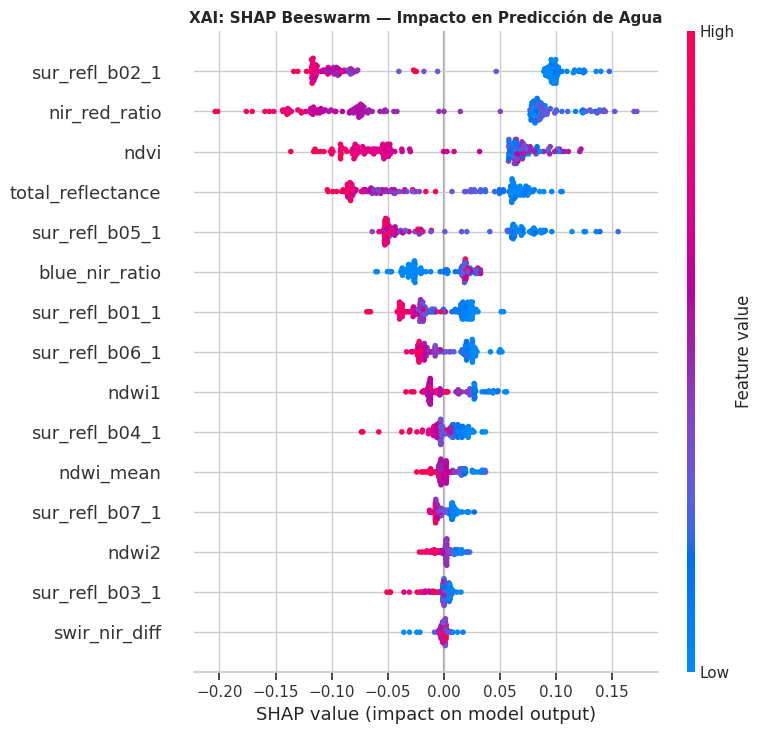

In [24]:
# --- SHAP: Bar Plot (importancia global promedio) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_water,
    X_shap_sample,
    feature_names=FEATURE_COLS,
    show=False,
    plot_type='dot'
)
plt.title('XAI: SHAP Beeswarm — Impacto en Predicción de Agua',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('output/xai2_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

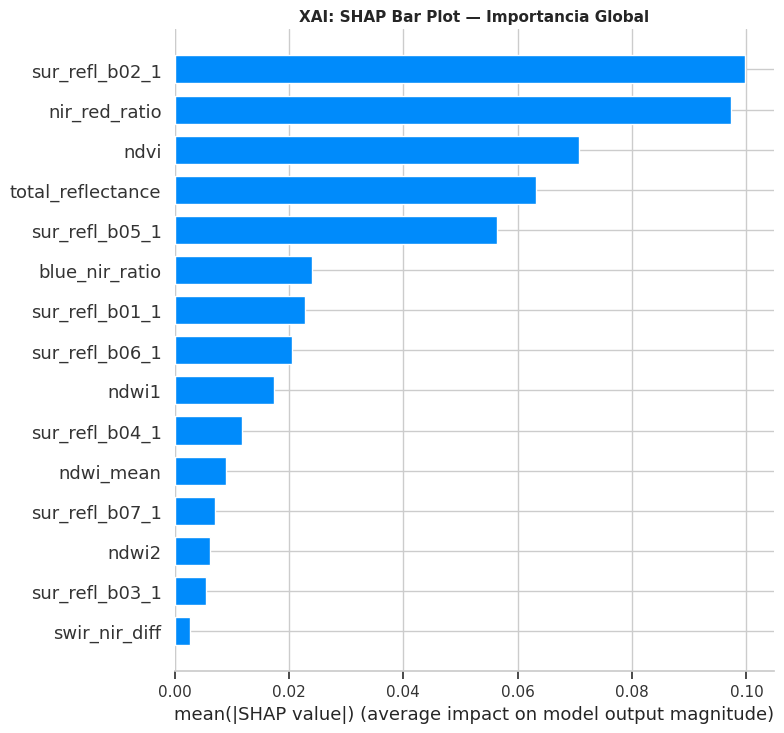

In [25]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv_water,
    X_shap_sample,
    feature_names=FEATURE_COLS,
    show=False,
    plot_type='bar'
)
plt.title('XAI: SHAP Bar Plot — Importancia Global',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('output/xai3_shap_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# --- Resumen Final del Modelo ---
print('=' * 55)
print('  RESUMEN — Clasificación de Agua (MODIS Lake Powell)')
print('=' * 55)
print(f'  Modelo       : Random Forest (n=150 árboles)')
print(f'  Features     : {len(FEATURE_COLS)} columnas (7 bandas + 3 índices + 5 eng.)')
print(f'  Train size   : {X_train.shape[0]:,} muestras')
print(f'  Test size    : {X_test.shape[0]:,} muestras')
print(f'  Accuracy     : {acc*100:.2f}%')
print(f'  AUC-ROC      : {auc:.4f}')
print(f'  Top feature  : {fi_df.iloc[0]["Feature"]} ({fi_df.iloc[0]["Importance"]:.4f})')
print('=' * 55)
print('✅ Parte 1 completada. Archivos guardados en /output/')

  RESUMEN — Clasificación de Agua (MODIS Lake Powell)
  Modelo       : Random Forest (n=150 árboles)
  Features     : 15 columnas (7 bandas + 3 índices + 5 eng.)
  Train size   : 640 muestras
  Test size    : 160 muestras
  Accuracy     : 97.50%
  AUC-ROC      : 0.9975
  Top feature  : sur_refl_b02_1 (0.1928)
✅ Parte 1 completada. Archivos guardados en /output/
